# basics

In [27]:
import strawberryfields as sf
from strawberryfields import ops

# create a 3-mode quantum program
prog = sf.Program(3)

with prog.context as q:
    ops.Sgate(0.54) | q[0]
    ops.Sgate(0.54) | q[1]
    ops.Sgate(0.54) | q[2]
    ops.BSgate(0.43, 0.1) | (q[0], q[2])
    ops.BSgate(0.43, 0.1) | (q[1], q[2])


In [28]:
prog.print()

Sgate(0.54, 0) | (q[0])
Sgate(0.54, 0) | (q[1])
Sgate(0.54, 0) | (q[2])
BSgate(0.43, 0.1) | (q[0], q[2])
BSgate(0.43, 0.1) | (q[1], q[2])


In [29]:
eng = sf.Engine("fock", backend_options={"cutoff_dim": 5})


In [30]:
result = eng.run(prog)

print(result.state)

<FockState: num_modes=3, cutoff=5, pure=True, hbar=2>


In [32]:
state = result.state
state.trace() 


0.9774831507527834

In [37]:
state.dm().shape

(5, 5, 5, 5, 5, 5)

In [45]:
import strawberryfields as sf
from strawberryfields import ops

# create a 2-mode quantum program
prog = sf.Program(2)

# create a free parameter named 'a'
a = prog.params('a')

# define the program
with prog.context as q:
    ops.Dgate(a ** 2)    | q[0]  # free parameter
    ops.MeasureX         | q[0]  # measure qumode 0, the result is used in the next operation
    ops.Sgate(1 - sf.math.sin(q[0].par)) | q[1]  # measured parameter
    ops.MeasureFock()    | q[1]

# initialize the Fock backend
eng = sf.Engine('fock', backend_options={'cutoff_dim': 5})

# run the program, with the free parameter 'a' bound to the value 0.9
result = eng.run(prog, args={'a': 0.9})

# Blackbird 

In [2]:
import numpy as np
import strawberryfields as sf
from strawberryfields.ops import *

prog = sf.Program(3)

with prog.context as q:
    S = Squeezed(1)
    S | q[0]
    S | q[1]

# Teleport

In [6]:
import strawberryfields as sf
from strawberryfields.ops import *

import numpy as np
from numpy import pi, sqrt

# set the random seed
# np.random.seed(42)

prog = sf.Program(3)

alpha = 1+0.5j
r = np.abs(alpha)
phi = np.angle(alpha)

with prog.context as q:
    # prepare initial states
    Coherent(r, phi) | q[0]
    Squeezed(-2) | q[1]
    Squeezed(2) | q[2]

    # apply gates
    BS = BSgate(pi/4, pi)
    BS | (q[1], q[2])
    BS | (q[0], q[1])

    # Perform homodyne measurements
    MeasureX | q[0]
    MeasureP | q[1]

    # Displacement gates conditioned on
    # the measurements
    Xgate(sqrt(2) * q[0].par) | q[2]
    Zgate(-sqrt(2) * q[1].par) | q[2]


In [7]:
eng = sf.Engine('fock', backend_options={"cutoff_dim": 15})

result = eng.run(prog, shots=1, modes=None, compile_options={})

In [8]:
print(result.state)
state = result.state

<FockState: num_modes=3, cutoff=15, pure=False, hbar=2>


In [9]:
print(result.samples)

[[2.78312783 1.82231822]]


In [11]:
rho2 = np.einsum('kkllij->ij', state.dm())
print(rho2.shape)

probs = np.real_if_close(np.diagonal(rho2))
print(probs)

(15, 15)
[2.84772679e-01 3.74547942e-01 1.96138833e-01 7.84000689e-02
 3.04816189e-02 1.42161058e-02 4.20422294e-03 2.05113143e-03
 3.88528764e-04 3.49843011e-04 1.22924744e-04 3.73967528e-04
 4.84811641e-04 1.91322315e-04 3.99199254e-04]


In [17]:
rho2 = state.reduced_dm(2) 
print(rho2.shape)

probs = np.real_if_close(np.diagonal(rho2))
print(probs)

(15, 15)
[2.84772679e-01 3.74547942e-01 1.96138833e-01 7.84000689e-02
 3.04816189e-02 1.42161058e-02 4.20422294e-03 2.05113143e-03
 3.88528764e-04 3.49843011e-04 1.22924744e-04 3.73967528e-04
 4.84811641e-04 1.91322315e-04 3.99199254e-04]


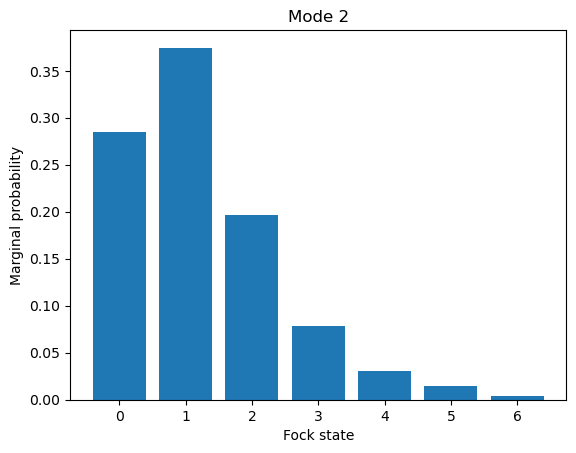

In [18]:
from matplotlib import pyplot as plt
plt.bar(range(7), probs[:7])
plt.xlabel('Fock state')
plt.ylabel('Marginal probability')
plt.title('Mode 2')
plt.show()

# Post select and measure

In [37]:
import numpy as np

# set the random seed
# np.random.seed(42)

import strawberryfields as sf
from strawberryfields.ops import *

prog = sf.Program(2)
eng = sf.Engine("fock", backend_options={"cutoff_dim": 6})

with prog.context as q:
    Fock(2) | q[0]
    Fock(3) | q[1]
    BSgate() | (q[0], q[1])
    MeasureFock() | q[0]

results = eng.run(prog)
print(results.samples)

[[1]]


In [38]:
prog2 = sf.Program(2)
with prog2.context as q:
    MeasureFock() | q[1]

results = eng.run(prog2)
print(results.samples[0][0])

4


## post select

In [80]:
prog = sf.Program(2)
eng = sf.Engine("fock", backend_options={"cutoff_dim": 6})

with prog.context as q:
    Fock(2) | q[0]
    Fock(3) | q[1]
    BSgate() | (q[0], q[1])
    MeasureFock(select=0) | q[0]
    MeasureFock() | q[1]

result = eng.run(prog)
print(result.samples)

[[0 5]]


In [81]:
prog = sf.Program(2)
eng = sf.Engine("gaussian")

with prog.context as q:
    S2gate(1) | (q[0], q[1])
    MeasureHomodyne(0, select=1) | q[0]

state = eng.run(prog).state

In [82]:
mu, cov = state.reduced_gaussian([1])
print(mu[0])

0.9640275698261899


## Classical processing

In [ ]:
prog = sf.Program(2)
with prog.context as q:
    MeasureFock() | q[0]
    Dgate(q[0].par ** 2) | q[1]

In [61]:
prog = sf.Program(2)
with prog.context as q:
    MeasureFock() | q[0]
    Dgate(sf.math.cos(q[0].par) + 2) | q[1]

# visualization

In [76]:
import strawberryfields as sf
from strawberryfields.ops import *

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [108]:
prog = sf.Program(1)

with prog.context as q:
    kappa = 1
    Dgate(1) | q[0]
    Kgate(kappa) | q[0]

eng = sf.Engine('fock', backend_options={"cutoff_dim": 10})
state = eng.run(prog).state

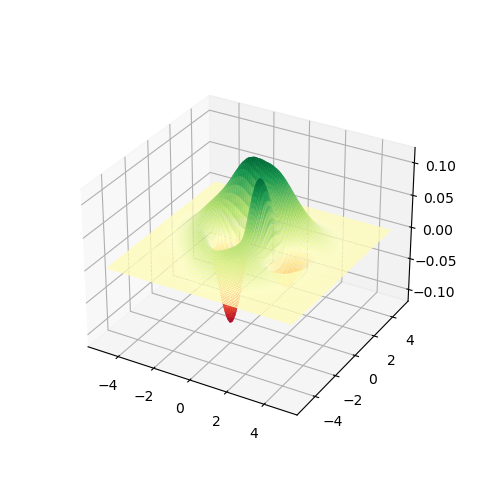

In [109]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
X = np.linspace(-5, 5, 100)
P = np.linspace(-5, 5, 100)
Z = state.wigner(0, X, P)  # Replace 'state' with your actual data source
X, P = np.meshgrid(X, P)

ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, P, Z, cmap="RdYlGn", lw=0.5, rstride=1, cstride=1)
fig.set_size_inches(4.8, 5)
# ax.set_axis_off()

plt.show()  # Explicitly show the plot

# bosonic backend

In [37]:
# Usual imports
import strawberryfields as sf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

# Simulation and cat state parameters
nmodes = 1
cutoff = 30
q = 10.0
p = 0.0
hbar = 2
alpha = (q + 1j * p) / np.sqrt(2 * hbar)
k = 1

x = 6
y = 0

beta = (x + 1j * y) / np.sqrt(2 * hbar)

# SF program
prog_cat_bosonic = sf.Program(nmodes)

with prog_cat_bosonic.context as q:
    sf.ops.Catstate(a=np.absolute(alpha), phi=np.angle(alpha), p=k) | q

eng = sf.Engine("bosonic", backend_options={"hbar": hbar})
state = eng.run(prog_cat_bosonic).state


In [ ]:
# We now plot it
xvec = np.linspace(-15, 15, 401)
W = state.wigner(mode=0, xvec=xvec, pvec=xvec)
Wp = np.round(W.real, 4)
scale = np.max(Wp.real)
nrm = mpl.colors.Normalize(-scale, scale)
plt.axes().set_aspect("equal")
plt.contourf(xvec, xvec, Wp, 60, cmap=cm.RdBu, norm=nrm)
plt.show()

In [10]:
means = state.means()
print(means)

covs = state.covs()
print(covs)

weights = state.weights()
print(weights)

[[ 10. +0.j   0. +0.j]
 [-10. +0.j  -0. +0.j]
 [  0. +0.j   0.-10.j]
 [  0. +0.j   0.+10.j]]
[[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]
[ 5.00000000e-01+0.00000000e+00j  5.00000000e-01+0.00000000e+00j
 -9.64374924e-23-1.18101866e-38j -9.64374924e-23+1.18101866e-38j]


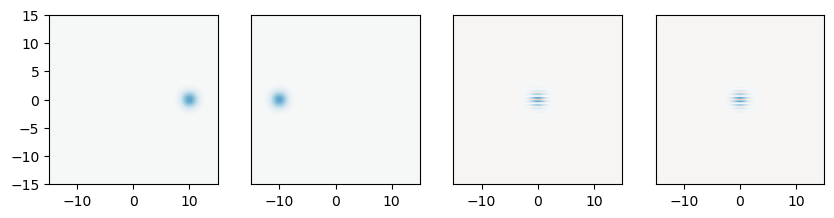

In [19]:
def gaussian_func_gen(mu, V):
    """Generates a function that when evaluated returns
    the value of a normalized Gaussian specified in terms
    of a vector of means and a covariance matrix.

    Args:
        mu (array): vector of means
        V (array): covariance matrix

    Returns:
        (callable): a normalized Gaussian function
    """
    Vi = np.linalg.inv(V)
    norm = 1.0 / np.sqrt(np.linalg.det(2 * np.pi * V))
    fun = lambda x: norm * np.exp(-0.5 * (x - mu) @ Vi @ (x - mu))
    return fun


def evaluate_fun(fun, xvec, yvec):
    """Evaluate a function a 2D in a grid of points.

    Args:
        fun (callable): function to evaluate
        xvec (array): values of the first variable of the function
        yvec (array): values of the second variable of the function

    Returns:
        (array): value of the function in the grid
    """
    return np.array([[fun(np.array([x, y])) for x in xvec] for y in xvec])


funs = [gaussian_func_gen(means[i], covs[i]) for i in range(len(means))]

Wps = [weights[i] * evaluate_fun(funs[i], xvec, xvec) for i in range(len(weights))]

fig, axs = plt.subplots(1, 4, figsize=(10, 2.2))
for i in range(4):
    Wp = np.round(Wps[i].real, 4)
    axs[i].contourf(xvec, xvec, Wp, 60, cmap=cm.RdBu, norm=nrm)
    if i != 0:
        axs[i].set_yticks([])
plt.show()

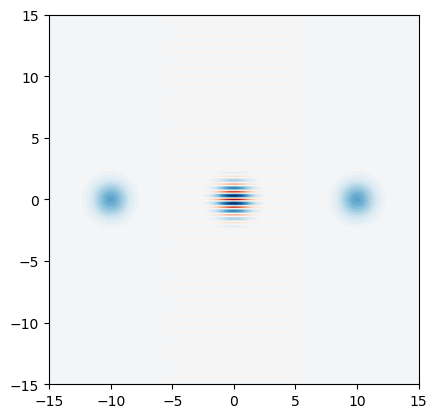

In [20]:
Wcat = sum(Wps)
plt.axes().set_aspect("equal")
plt.contourf(xvec, xvec, Wcat.real, 60, cmap=cm.RdBu, norm=nrm)
plt.show()

In [40]:
x = 6
y = 0

beta = (x + 1j * y) / np.sqrt(2 * hbar)
prog_cat_bosonic_displaced = sf.Program(nmodes)

with prog_cat_bosonic_displaced.context as q:
    sf.ops.Catstate(a=np.absolute(alpha), phi=np.angle(alpha), p=k) | q
    sf.ops.Dgate(beta) | q

eng = sf.Engine("bosonic", backend_options={"hbar": hbar})
state = eng.run(prog_cat_bosonic_displaced).state

In [2]:
xvec = np.linspace(-20, 20, 200)
Wps = state.wigner(mode=0, xvec=xvec, pvec=xvec)
plt.axes().set_aspect("equal")
contour  = plt.contourf(xvec, xvec, Wps, 60, cmap=cm.RdBu, norm=nrm)
plt.colorbar(contour, label="Wigner Function Value")
plt.show()

NameError: name 'np' is not defined

# Time-domain


In [1]:
import strawberryfields as sf
from strawberryfields.ops import Sgate, BSgate, Rgate, MeasureHomodyne
import numpy as np

np.random.seed(42)
n = 20

r = 1.0
length = n - 1
alpha = [np.pi / 4] * length
phi = [0] * length
theta = [0] * length

prog0 = sf.Program(n)
with prog0.context as q:
    for i in range(n - 1):
        Sgate(r) | q[i + 1]
        BSgate(alpha[i]) | (q[i], q[i + 1])
        Rgate(phi[i]) | q[i + 1]
        MeasureHomodyne(theta[i]) | q[i]
eng0 = sf.Engine("gaussian")
result0 = eng0.run(prog0)

In [2]:
print(result0.samples)


[[-0.10417347  0.60228311 -0.00316101  0.34561221  0.25296546 -0.13280689
  -0.67985316 -0.19192785  0.12600941 -0.51235116 -0.07813559 -0.52072239
   0.04318271  0.13989725 -0.10611505  0.68226231 -0.38850925 -0.44870008
  -0.72062428]]


In [4]:
from strawberryfields.tdm import shift_by

np.random.seed(42)  # We set the seed to facilitate comparison
prog1 = sf.Program(2)
n = 20
with prog1.context as q:
    for i in range(n - 1):
        Sgate(r) | q[1]
        BSgate(alpha[i]) | (q[0], q[1])
        Rgate(phi[i]) | q[1]
        MeasureHomodyne(theta[i]) | q[0]
        # Note that only position 0 of q is measured
        q = shift_by(q, 1)
eng1 = sf.Engine("gaussian")
result1 = eng1.run(prog1)
print(result1.samples)

[[-0.72062428 -0.44870008]]


In [5]:
print(result1.samples_dict)

{0: [array([-0.10417347]), array([-0.00316101]), array([0.25296546]), array([-0.67985316]), array([0.12600941]), array([-0.07813559]), array([0.04318271]), array([-0.10611505]), array([-0.38850925]), array([-0.72062428])], 1: [array([0.60228311]), array([0.34561221]), array([-0.13280689]), array([-0.19192785]), array([-0.51235116]), array([-0.52072239]), array([0.13989725]), array([0.68226231]), array([-0.44870008])]}


In [6]:
np.random.seed(42)  # We set the seed to facilitate comparison
N = 2  # Number of concurrent modes
prog2 = sf.TDMProgram(N=N)

with prog2.context(alpha, phi, theta) as (p, q):
    Sgate(r, 0) | q[1]
    BSgate(p[0]) | (q[0], q[1])
    Rgate(p[1]) | q[1]
    MeasureHomodyne(p[2]) | q[0]
eng2 = sf.Engine("gaussian")
result2 = eng2.run(prog2)
print(result2.samples)

[[[-0.10417347  0.60228311 -0.00316101  0.34561221  0.25296546
   -0.13280689 -0.67985316 -0.19192785  0.12600941 -0.51235116
   -0.07813559 -0.52072239  0.04318271  0.13989725 -0.10611505
    0.68226231 -0.38850925 -0.44870008 -0.72062428]]]


In [9]:
def singleloop(r, alpha, phi, theta, shots):
    """Single loop program.

    Args:
        r (float): squeezing parameter
        alpha (Sequence[float]): beamsplitter angles
        phi (Sequence[float]): rotation angles
        theta (Sequence[float]): homodyne measurement angles
        shots (int): number of times the circuit is sampled
    Returns:
        list: homodyne samples from the single loop simulation
    """

    prog = sf.TDMProgram(N=2)
    with prog.context(alpha, phi, theta) as (p, q):
        Sgate(r, 0) | q[1]
        BSgate(p[0]) | (q[0], q[1])
        Rgate(p[1]) | q[1]
        MeasureHomodyne(p[2]) | q[0]
    eng = sf.Engine("gaussian")
    result = eng.run(prog, shots=shots)
    # We only want the samples from concurrent mode 0
    return result.samples_dict[0]

In [10]:
np.random.seed(42)  # We set the seed to facilitate comparison
singleloop(r, alpha, phi, theta, 1)  # We want 1 shot

array([[-0.10417347,  0.60228311, -0.00316101,  0.34561221,  0.25296546,
        -0.13280689, -0.67985316, -0.19192785,  0.12600941, -0.51235116,
        -0.07813559, -0.52072239,  0.04318271,  0.13989725, -0.10611505,
         0.68226231, -0.38850925, -0.44870008, -0.72062428]])

In [11]:
r = 2.0
alpha = [np.pi / 4, 0]
phi = [0, np.pi / 2]
theta = [0, 0]  # We will measure the positions by setting theta = [0,0]
shots = 2500

samplesEPRxx = singleloop(r, alpha, phi, theta, shots)

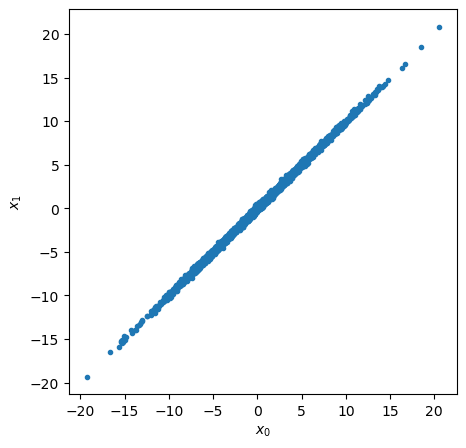

In [12]:
samplesxx = samplesEPRxx.T
x0 = samplesxx[0]
x1 = samplesxx[1]

# We now want to look at the samples
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.plot(x0, x1, ".")
plt.xlabel(r"$x_0$")
plt.ylabel(r"$x_{1}$")
plt.show()